# 02 — Monte Carlo Option Pricing

Instead of solving the Black-Scholes PDE analytically, we simulate many possible stock price paths and estimate the option price as the discounted expected payoff.

Under risk-neutral measure, the stock price follows **Geometric Brownian Motion**:

$$S(t + \Delta t) = S(t) \cdot \exp\left[(r - \tfrac{1}{2}\sigma^2)\Delta t + \sigma\sqrt{\Delta t}\, Z\right], \quad Z \sim \mathcal{N}(0,1)$$

The call price is then:

$$C \approx e^{-rT} \cdot \frac{1}{N} \sum_{i=1}^{N} \max(S_T^{(i)} - K,\, 0)$$

By the **Law of Large Numbers**, this converges to the true Black-Scholes price as $N \to \infty$.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from monte_carlo import simulate_paths, mc_call_price
from black_scholes import call_price

In [2]:
S     = 150.0
K     = 150.0
T     = 0.25
r     = 0.05
sigma = 0.20

## Simulated price paths
Each line is one possible future for the stock. The spread of terminal values determines the option price.

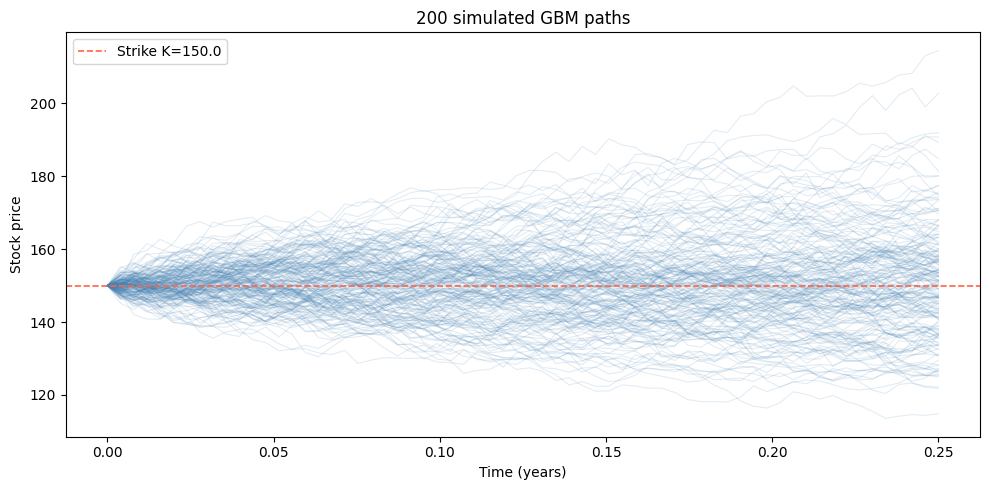

In [3]:
np.random.seed(42)
paths = simulate_paths(S, T, r, sigma, n_simulations=200, n_steps=63)  # ~63 trading days in a quarter

t_axis = np.linspace(0, T, paths.shape[0])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_axis, paths, alpha=0.15, linewidth=0.8, color='steelblue')
ax.axhline(K, color='tomato', linestyle='--', linewidth=1.2, label=f'Strike K={K}')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Stock price')
ax.set_title('200 simulated GBM paths')
ax.legend()
plt.tight_layout()
plt.show()

## Distribution of terminal stock prices
GBM implies log-normally distributed terminal prices. The area to the right of the strike is the probability of the call expiring in the money.

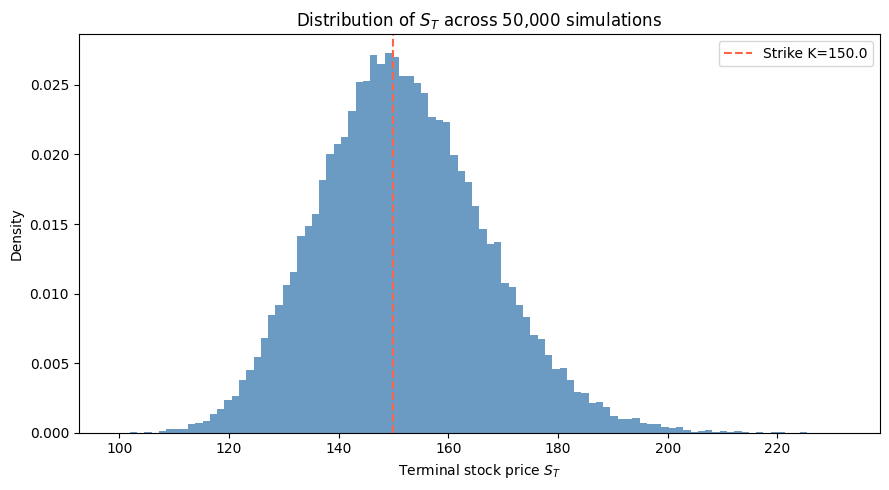

Probability of finishing in the money: 52.64%


In [4]:
np.random.seed(42)
large_paths = simulate_paths(S, T, r, sigma, n_simulations=50_000, n_steps=63)
S_T = large_paths[-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(S_T, bins=100, color='steelblue', edgecolor='none', alpha=0.8, density=True)
ax.axvline(K, color='tomato', linestyle='--', linewidth=1.5, label=f'Strike K={K}')
ax.set_xlabel('Terminal stock price $S_T$')
ax.set_ylabel('Density')
ax.set_title('Distribution of $S_T$ across 50,000 simulations')
ax.legend()
plt.tight_layout()
plt.show()

itm_prob = np.mean(S_T > K)
print(f"Probability of finishing in the money: {itm_prob:.2%}")

## MC price vs. Black-Scholes price
Both methods should give the same answer. Any gap is pure simulation noise — it shrinks as $N$ grows.

In [5]:
bs_price = call_price(S, K, T, r, sigma)

np.random.seed(0)
mc_price, mc_se = mc_call_price(S, K, T, r, sigma, n_simulations=100_000)

print(f"Black-Scholes price : ${bs_price:.4f}")
print(f"Monte Carlo price   : ${mc_price:.4f} ± {mc_se:.4f} (1 std error)")
print(f"Difference          : ${abs(bs_price - mc_price):.4f}")

Black-Scholes price : $6.9225
Monte Carlo price   : $6.9316 ± 0.0313 (1 std error)
Difference          : $0.0091


## Convergence: MC price as $N$ increases
The standard error of a Monte Carlo estimate scales as $1/\sqrt{N}$. Doubling accuracy requires 4× the simulations.

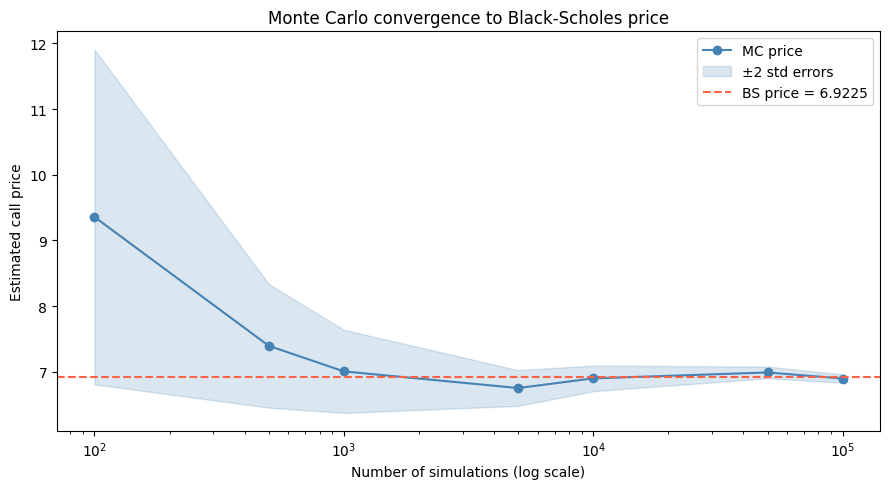

In [6]:
np.random.seed(1)
n_values  = [100, 500, 1_000, 5_000, 10_000, 50_000, 100_000]
mc_prices = []
mc_errors = []

for n in n_values:
    price, se = mc_call_price(S, K, T, r, sigma, n_simulations=n)
    mc_prices.append(price)
    mc_errors.append(se)

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(n_values, mc_prices, 'o-', color='steelblue', label='MC price')
ax.fill_between(
    n_values,
    [p - 2*e for p, e in zip(mc_prices, mc_errors)],
    [p + 2*e for p, e in zip(mc_prices, mc_errors)],
    alpha=0.2, color='steelblue', label='±2 std errors'
)
ax.axhline(bs_price, color='tomato', linestyle='--', label=f'BS price = {bs_price:.4f}')
ax.set_xlabel('Number of simulations (log scale)')
ax.set_ylabel('Estimated call price')
ax.set_title('Monte Carlo convergence to Black-Scholes price')
ax.legend()
plt.tight_layout()
plt.show()